# Embeddings & attention — how an LLM works, built small

Your first three notebooks predicted **yes/no from two numbers**. But the model you're
reading these words through — an LLM — works with *language*. How does a neural network,
which only does arithmetic, deal with words like "king" or "banana"?

Two ideas do almost all the work, and they're the heart of the **transformer**, the
architecture behind ChatGPT and Claude:

1. **Embeddings** — turn each word into a *vector*, so that **direction carries meaning**.
   Similar words end up near each other, and you can literally do arithmetic on meaning:
   `king − man + woman ≈ queen`.
2. **Attention** — let every word *look at* every other word and pull in the ones that
   matter, so meaning depends on **context**.

We'll build both from scratch on a tiny hand-made vocabulary — no training, no downloads —
so you can *see* every step. At the end we'll be honest about the (few) things a real LLM
adds on top.

Run top to bottom; the interactive cells have sliders and dropdowns.

## 1. Setup

New face here: `PCA` from scikit-learn. Embeddings live in many dimensions; PCA lets us
**flatten them to 2D so we can plot them** (keeping as much of the spread as possible).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 6)
plt.rcParams["figure.dpi"] = 100

ACCENT = "#2a9d8f"
print("ready")

ready


## 2. Tokens → embeddings: words become vectors

A network can't multiply "king" by a weight — it needs numbers. So every word (**token**)
is assigned a vector of numbers called its **embedding**.

To keep things transparent, we'll *hand-build* the embeddings using meaning-features we
choose ourselves — is it royal? is it female? an animal? a food? an action? Each word
becomes a row of these features.

> ⚠️ **The one simplification to remember:** in a real model these numbers are **learned**
> automatically from reading enormous amounts of text, they number in the hundreds or
> thousands per word, and *no human labels the dimensions* — the model invents its own.
> We hand-label them only so the picture is readable.

In [2]:
features = ["royal", "gender(f+/m-)", "human", "young", "animal", "feline",
            "canine", "food", "fruit", "action"]
TABLE = {
    "king":     [1, -1, 1, 0, 0, 0, 0, 0, 0, 0],
    "queen":    [1,  1, 1, 0, 0, 0, 0, 0, 0, 0],
    "prince":   [1, -1, 1, 1, 0, 0, 0, 0, 0, 0],
    "princess": [1,  1, 1, 1, 0, 0, 0, 0, 0, 0],
    "man":      [0, -1, 1, 0, 0, 0, 0, 0, 0, 0],
    "woman":    [0,  1, 1, 0, 0, 0, 0, 0, 0, 0],
    "cat":      [0,  0, 0, 0, 1, 1, 0, 0, 0, 0],
    "lion":     [0,  0, 0, 0, 1, 1, 0, 0, 0, 0],
    "dog":      [0,  0, 0, 0, 1, 0, 1, 0, 0, 0],
    "apple":    [0,  0, 0, 0, 0, 0, 0, 1, 1, 0],
    "bread":    [0,  0, 0, 0, 0, 0, 0, 1, 0, 0],
    "run":      [0,  0, 0, 0, 0, 0, 0, 0, 0, 1],
    "sleep":    [0,  0, 0, 0, 0, 0, 0, 0, 0, 1],
}
words = list(TABLE)
E = np.array([TABLE[w] for w in words], dtype=float)

# a tiny random jitter so words with identical features aren't perfectly tied
E = E + np.random.default_rng(0).normal(0, 0.05, E.shape)

def vec(w):
    return E[words.index(w)]

print(f"{len(words)} words, each a {E.shape[1]}-dimensional vector")
print("features:", features)
print("\nembedding for 'king':", np.round(vec("king"), 2))

13 words, each a 10-dimensional vector
features: ['royal', 'gender(f+/m-)', 'human', 'young', 'animal', 'feline', 'canine', 'food', 'fruit', 'action']

embedding for 'king': [ 1.01 -1.01  1.03  0.01 -0.03  0.02  0.07  0.05 -0.04 -0.06]


## 3. Picture the meaning space (PCA → 2D)

Our vectors have 9 dimensions — impossible to plot directly. **PCA** squashes them down to
the 2 directions that carry the most variation, so we can see them on a flat page. Watch
the words fall into natural clusters: royals, plain humans, animals, foods, actions.

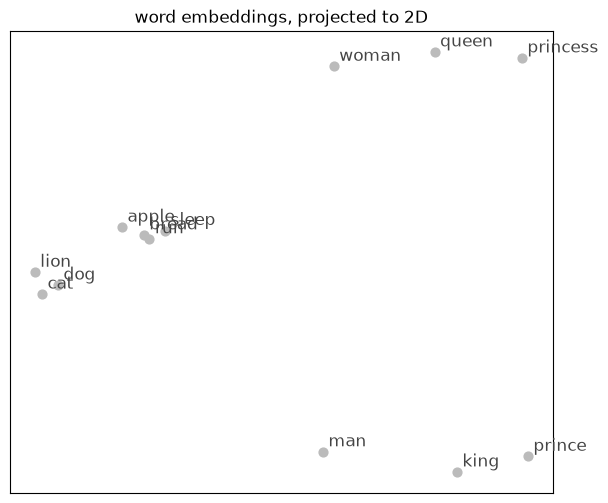

In [3]:
coords = PCA(n_components=2).fit_transform(E)

def show_space(highlight=None, neighbors=()):
    fig, ax = plt.subplots()
    ax.scatter(coords[:, 0], coords[:, 1], s=40, color="#bbbbbb", zorder=2)
    for i, w in enumerate(words):
        color, weight = "#444", "normal"
        if w == highlight:  color, weight = "#e63946", "bold"
        elif w in neighbors: color, weight = ACCENT, "bold"
        ax.annotate(w, (coords[i, 0], coords[i, 1]),
                    fontsize=12, color=color, fontweight=weight,
                    xytext=(4, 4), textcoords="offset points")
    if highlight is not None:
        i = words.index(highlight)
        ax.scatter([coords[i, 0]], [coords[i, 1]], s=140, color="#e63946", zorder=3)
    ax.set_title("word embeddings, projected to 2D")
    ax.set_xticks([]); ax.set_yticks([])
    plt.show()

show_space()

### Which words are "closest" in meaning?

Closeness is measured with **cosine similarity** — how aligned two vectors are
(1 = same direction, 0 = unrelated). Pick a word and see its nearest neighbors light up.

In [9]:
def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))

def nearest(word, k=3):
    v = vec(word)
    sims = [(w, cosine(v, vec(w))) for w in words if w != word]
    return sorted(sims, key=lambda t: -t[1])[:k]

def neighbors_of(word, k):
    nb = nearest(word, k)
    print(f"nearest to '{word}':")
    for w, s in nb:
        print(f"    {w:9s}  similarity {s:.2f}")
    show_space(highlight=word, neighbors=[w for w, _ in nb])

interact(
    neighbors_of,
    word=Dropdown(options=words, value="cat", description="word"),
    k=IntSlider(value=3, min=1, max=6, step=1, description="# neighbors"),
);

interactive(children=(Dropdown(description='word', index=6, options=('king', 'queen', 'prince', 'princess', 'm…

## 4. Meaning is a *direction*: word arithmetic

Here's the magic that first stunned people. If direction encodes meaning, then the *step*
from `man` to `king` (add "royalty") should be the same step as from `woman` to `queen`.
So:

$$\text{king} - \text{man} + \text{woman} \approx \text{queen}$$

We compute that vector and find the nearest real word to it. Try other analogies too
(a is to b as c is to ?).

In [5]:
def analogy(a, b, c):
    # a is to b as c is to ?   ->   nearest word to (b - a + c)
    target = vec(b) - vec(a) + vec(c)
    ranked = sorted(((w, cosine(target, vec(w))) for w in words),
                    key=lambda t: -t[1])
    answer = [w for w, _ in ranked if w not in (a, b, c)][0]

    fig, ax = plt.subplots()
    ax.scatter(coords[:, 0], coords[:, 1], s=30, color="#cccccc")
    for i, w in enumerate(words):
        ax.annotate(w, (coords[i, 0], coords[i, 1]), fontsize=10, color="#666",
                    xytext=(4, 4), textcoords="offset points")
    # draw the two parallel "meaning steps": a->b and c->answer
    for (u, v_, col) in [(a, b, "#e63946"), (c, answer, ACCENT)]:
        p, q = coords[words.index(u)], coords[words.index(v_)]
        ax.annotate("", xy=q, xytext=p, arrowprops=dict(arrowstyle="->", color=col, lw=2))
    ax.set_title(f"{a} : {b}   ::   {c} : {answer}")
    ax.set_xticks([]); ax.set_yticks([])
    plt.show()
    print(f"{a} - {b} ... {c}  ->  '{answer}'   (top-3: {[w for w,_ in ranked if w not in (a,b,c)][:3]})")

interact(
    analogy,
    a=Dropdown(options=words, value="man",   description="a"),
    b=Dropdown(options=words, value="king",  description="b"),
    c=Dropdown(options=words, value="woman", description="c"),
);

interactive(children=(Dropdown(description='a', index=4, options=('king', 'queen', 'prince', 'princess', 'man'…

### Why does that work? It's just arithmetic on meaning

Each *direction* in the space is a unit of meaning, so subtracting a vector **removes**
that meaning and adding one **puts it back**. Think of the four words as a parallelogram:
the step `man → king` means "add royalty", and the step `woman → queen` means the *same
thing* — so they're the same arrow, just starting from different places.

```
   man  ──"add royalty"──►  king
    │                        │
"male → female"        "male → female"
    │                        │
    ▼                        ▼
  woman ──"add royalty"──► queen
```

Using this notebook's actual features (just the four that matter here):

| word  | royal | gender | human | young |
|-------|:-----:|:------:|:-----:|:-----:|
| king  |   1   |  −1    |   1   |   0   |
| man   |   0   |  −1    |   1   |   0   |
| woman |   0   |  +1    |   1   |   0   |
| queen |   1   |  +1    |   1   |   0   |

Do the sum **feature by feature** — exactly what the code does:

```
king − man + woman:
  royal :   1 − 0 + 0     = 1   → royal  ✓
  gender:  −1 − (−1) + 1  = 1   → female ✓   (king's −1 cancels man's −1; woman's +1 survives)
  human :   1 − 1 + 1     = 1   → human  ✓
  young :   0 − 0 + 0     = 0   → adult  ✓
  result = [1, +1, 1, 0]  ==  queen   exactly
```

What each step did:

- **`− man`** cancels everything `king` and `man` share (male, human, adult), leaving
  essentially the lone **"royal"** feature.
- **`+ woman`** adds "human" back — but this time **female**.
- Sum = royal + female + human = **queen**. The gender flipped only because we subtracted
  a male word and added a female one; royalty survived because only `king` carried it.

The striking part in a *real* model: nobody defines these features — the embeddings are
**learned** from text, yet directions like "gender", "royalty", or "plural" emerge on their
own, because words that behave alike in language end up pointing alike in the space. So
relationships become geometry: `Paris − France + Italy ≈ Rome`, `walk → walking` is the
same step as `swim → swimming`.

> **Caveat (why the code takes the *nearest* word):** our table is hand-built, so the
> parallelogram is *perfect*. In real learned embeddings it's only *approximate* —
> `king − man + woman` lands in a neighborhood *near* queen, not exactly on it. The
> structure is real; it's just fuzzy.

## 5. The one operation attention is built from: similarity → weights

Attention needs two little pieces you've almost already met.

**Dot product = alignment.** `a · b` is large when two vectors point the same way — it's
the unnormalized cousin of cosine similarity. This is how a word measures "how relevant is
that other word to me?"

**Softmax = turn scores into weights.** Given a row of raw scores, softmax makes them all
positive and sum to 1 — a set of *weights*. It's the multi-option cousin of the **sigmoid**
you used for yes/no. A **temperature** controls the sharpness: low temperature → almost all
weight on the single best score; high temperature → spread out, nearly equal.

In [ ]:
def softmax(z, temp=1.0):
    z = np.array(z, float) / temp
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()

scores = [3.0, 1.0, 0.2, 2.5]      # example relevance scores for 4 "words"
labels = ["w1", "w2", "w3", "w4"]

def show_softmax(temperature):
    weights = softmax(scores, temperature)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(labels, weights, color=ACCENT)
    ax.set_ylim(0, 1)
    ax.set_title(f"softmax weights (temperature={temperature:.2f})  —  they always sum to 1")
    for i, w in enumerate(weights):
        ax.text(i, w + 0.02, f"{w:.2f}", ha="center")
    plt.show()

interact(show_softmax,
         temperature=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1,
                                 description="temperature"));

interactive(children=(FloatSlider(value=1.0, description='temperature', max=5.0, min=0.1), Output()), _dom_cla…

## 6. Self-attention, from scratch

Now the payoff. Take a little "sentence" — just a list of words. **Self-attention** lets
each word build a new version of itself by mixing in the words it finds relevant.

For every word we form three vectors (in a real transformer these come from *learned*
projections; here we keep it transparent and use the embedding itself for all three):

- **Query (Q)** — "what am I looking for?"
- **Key (K)** — "what do I offer?"
- **Value (V)** — "what I'll contribute if attended to."

The recipe (this is the entire mechanism):

```
scores  = Q · Kᵀ / √d      # every word scores every word by alignment
A       = softmax(scores)  # turn each row into weights that sum to 1
output  = A · V            # each word = weighted blend of all values
```

The matrix **A** is the star: `A[i, j]` = how much word *i* attends to word *j*.

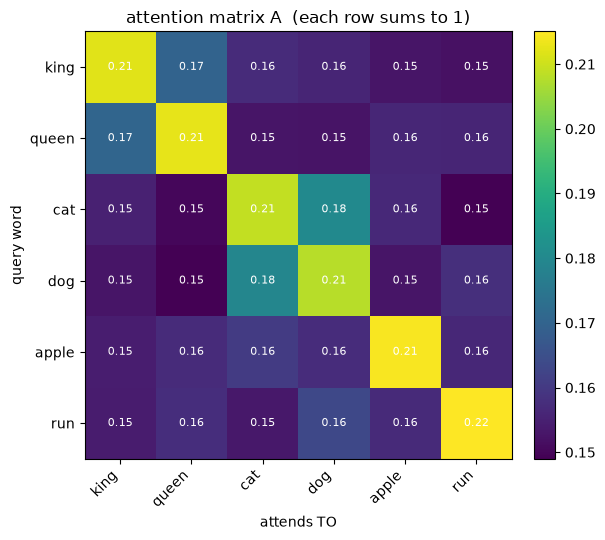

Every word attends most to itself — then to related words (king↔queen, cat↔dog).


In [7]:
def attention(sentence, temp=1.0):
    X = np.array([vec(w) for w in sentence])
    X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)   # unit length: dot == cosine
    d = X.shape[1]
    scores = (X @ X.T) / np.sqrt(d)
    A = np.vstack([softmax(row, temp) for row in scores])       # softmax over each row
    out = A @ X
    return A, out

sentence = ["king", "queen", "cat", "dog", "apple", "run"]
A, _ = attention(sentence)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(A, cmap="viridis")
ax.set_xticks(range(len(sentence))); ax.set_xticklabels(sentence, rotation=45, ha="right")
ax.set_yticks(range(len(sentence))); ax.set_yticklabels(sentence)
ax.set_xlabel("attends TO"); ax.set_ylabel("query word")
ax.set_title("attention matrix A  (each row sums to 1)")
for i in range(len(sentence)):
    for j in range(len(sentence)):
        ax.text(j, i, f"{A[i,j]:.2f}", ha="center", va="center",
                color="white" if A[i, j] < 0.35 else "black", fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()
print("Every word attends most to itself — then to related words (king↔queen, cat↔dog).")

## 7. 🎛️ Read the attention

Pick a **query word** and see how it spreads its attention over the others. Mask the
diagonal (a word's attention to itself) to make the *cross-word* relationships pop, and use
**temperature** to sharpen or blur the focus — low temperature makes each word commit to its
single most-related neighbor.

In [ ]:
def explore_attention(query, temperature, mask_self):
    A, _ = attention(sentence, temperature)
    i = sentence.index(query)
    row = A[i].copy()
    if mask_self:
        row[i] = 0.0
        row = row / (row.sum() + 1e-9)

    fig, ax = plt.subplots(figsize=(8, 4))
    colors = [ACCENT if k != i else "#e63946" for k in range(len(sentence))]
    ax.bar(sentence, row, color=colors)
    ax.set_ylim(0, 1)
    ax.set_title(f"'{query}' attends to…   (temperature={temperature:.2f}"
                 + (", self masked)" if mask_self else ")"))
    for k, v in enumerate(row):
        ax.text(k, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
    plt.show()
    top = sorted([(w, row[k]) for k, w in enumerate(sentence) if not (mask_self and k == i)],
                 key=lambda t: -t[1])[0]
    print(f"'{query}' attends most to: '{top[0]}' ({top[1]:.2f})")

interact(
    explore_attention,
    query=Dropdown(options=sentence, value="king", description="query word"),
    temperature=FloatSlider(value=1.0, min=0.1, max=4.0, step=0.1, description="temperature"),
    mask_self=widgets.Checkbox(value=True, description="mask self-attention"),
);

interactive(children=(Dropdown(description='query word', options=('king', 'queen', 'cat', 'dog', 'apple', 'run…

## 8. What you just built is (most of) a transformer

That block — embeddings in, attention mix, vectors out — is the core of every large
language model. Stack it up and train it, and you get an LLM:

```
   words
     │  ── embedding lookup ─────────────►  vectors  (Section 2)
     │  ── + positional info ────────────►  "where in the sentence" added in
     ▼
 ┌─────────────────────────────────────┐
 │  self-attention  (Sections 6–7)      │   ×  many layers stacked
 │  + a small feed-forward net          │      (like Notebook 1, per position)
 └─────────────────────────────────────┘
     │
     ▼  ── predict the NEXT word ───────►  softmax over the whole vocabulary
```

**What a real LLM adds that we skipped — honestly:**

- **Learned Q, K, V.** We reused the embedding for all three; real models learn three
  separate projection matrices (trained exactly like Notebook 2 — `loss.backward()`).
- **Multiple heads.** Several attention matrices in parallel, each free to focus on a
  different kind of relationship (grammar, topic, …).
- **Many layers.** Dozens to hundreds of these blocks stacked, each refining the meaning.
- **Positional encoding.** Attention alone is order-blind; models add a signal for *where*
  each word sits.
- **Massive training.** Trillions of words, learning to **predict the next token** — the
  same loss/gradient/overfitting machinery from Notebooks 1–3, just enormous.

The ideas, though, are exactly the ones you just coded by hand.

## 9. Recap — and where this goes next

- **Embeddings** turn tokens into vectors where *direction is meaning* — similar words
  cluster, and meaning can be added and subtracted (`king − man + woman ≈ queen`).
- **Attention** lets each token score every other (dot product), turn those scores into
  weights (**softmax**), and blend in the relevant ones — so meaning becomes contextual.
- **Softmax** shows up again and again — it's just the many-option **sigmoid**.

You've now seen the whole stack in miniature: a neuron and gradients (Notebook 1), a real
framework (2), generalization and overfitting (3), and the transformer's core (this one).

**Your next rung:** turn this into a *tiny working language model* — add learned Q/K/V and
positional encoding, stack a couple of layers, and train it to predict the next character
on a small text. That's exactly what Karpathy's **nanoGPT / "makemore"** does, and every
tool you'd need is in the `.venv` already. The paper to read alongside it is
**"Attention Is All You Need"** (2017) — the eight pages this notebook unpacks.